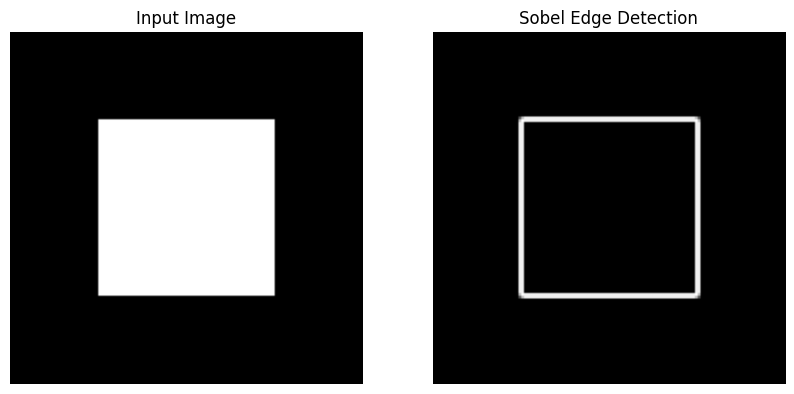

In [ ]:
#Sobel Edge Detection
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

def sobel_edge_detection(image):
    # Sobel kernels
    sx = np.array([[-1, 0, ],
                   [-2, 0, 2],
                   [-1, 0, 1]])

    sy = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]])

    Ix = ndimage.convolve(image, sx, mode='constant')
    Iy = ndimage.convolve(image, sy, mode='constant')

    magnitude = np.hypot(Ix, Iy)
    return magnitude / magnitude.max()  # Normalize to 0–1

# Create synthetic input image
img = np.zeros((128, 128))
img[32:96, 32:96] = 1.0  # White square

# Apply Sobel edge detection
edges = sobel_edge_detection(img)

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.show()

Detected lines (rho, theta):
(np.float64(0.0), np.float64(-0.7853981633974483))


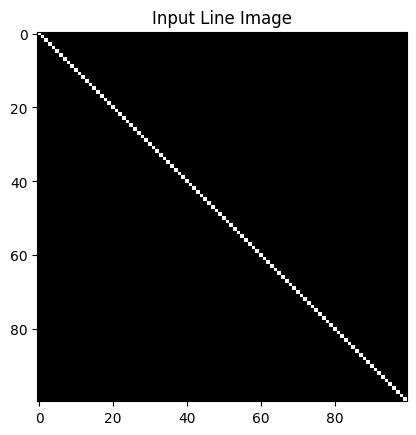

In [ ]:
#Line Detection using Hough Transform
import numpy as np
import matplotlib.pyplot as plt

def hough_line_detection(binary_edges, theta_step=0.5, threshold_ratio=0.6):
    h, w = binary_edges.shape
    diag = int(np.ceil(np.hypot(h, w)))

    rhos = np.linspace(-diag, diag, 2 * diag + 1)
    thetas = np.deg2rad(np.arange(-90, 90, theta_step))

    accumulator = np.zeros((len(rhos), len(thetas)), dtype=int)

    y, x = np.nonzero(binary_edges > 0.1)

    for px, py in zip(x, y):
        for t_idx, theta in enumerate(thetas):
            rho = px * np.cos(theta) + py * np.sin(theta)
            rho_idx = np.argmin(np.abs(rhos - rho))
            accumulator[rho_idx, t_idx] += 1

    max_votes = accumulator.max()
    peaks = np.argwhere(accumulator >= threshold_ratio * max_votes)

    lines = []
    for rho_idx, theta_idx in peaks:
        lines.append((rhos[rho_idx], thetas[theta_idx]))

    return lines, accumulator

img = np.zeros((100, 100))
for i in range(100):
    img[i, i] = 1.0

lines, acc = hough_line_detection(img)

print("Detected lines (rho, theta):")
for line in lines:
    print(line)

plt.imshow(img, cmap='gray')
plt.title("Input Line Image")
plt.show()

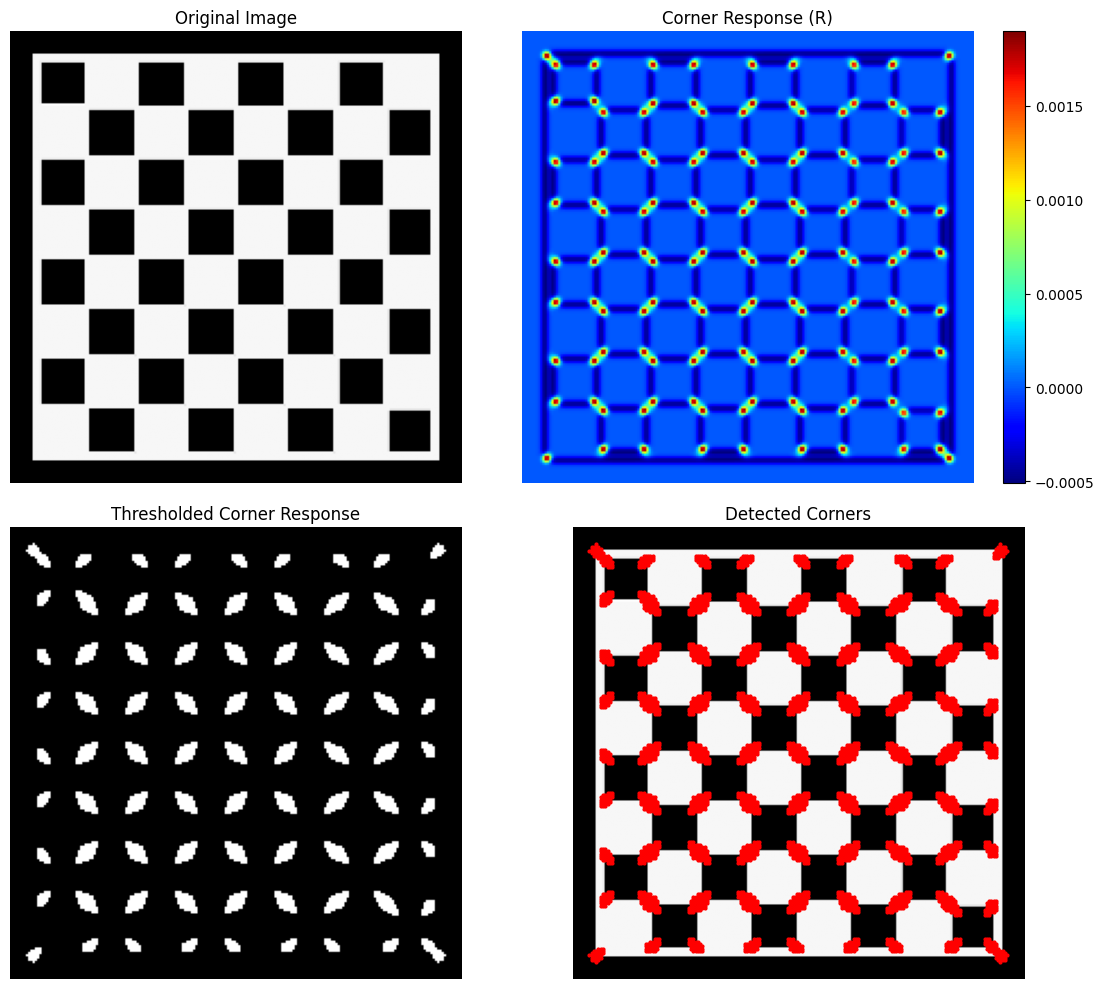

In [ ]:
#Harris Corner Detection
import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

# Load image (grayscale)
img = cv2.imread('/content/chessboard.png', cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32) / 255.0

def harris_corners(gray, sigma=1.5, k=0.05, thresh=0.01):
    # Gradients
    Ix = ndimage.sobel(gray, axis=1)
    Iy = ndimage.sobel(gray, axis=0)

    # Second moment matrix components
    Ix2 = ndimage.gaussian_filter(Ix**2, sigma)
    Iy2 = ndimage.gaussian_filter(Iy**2, sigma)
    Ixy = ndimage.gaussian_filter(Ix * Iy, sigma)

    # Harris response
    det = Ix2 * Iy2 - Ixy**2
    trace = Ix2 + Iy2
    R = det - k * (trace**2)

    # Threshold
    R_thresh = R > thresh * R.max()
    corners = np.argwhere(R_thresh)

    return R, R_thresh, corners

# Run Harris detector
R, R_thresh, corners = harris_corners(img)

# Plot results
plt.figure(figsize=(12, 10))

# 1. Original Image
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# 2. Corner Response
plt.subplot(2, 2, 2)
plt.imshow(R, cmap='jet')
plt.title("Corner Response (R)")
plt.colorbar()
plt.axis('off')

# 3. Thresholded Corner Response
plt.subplot(2, 2, 3)
plt.imshow(R_thresh, cmap='gray')
plt.title("Thresholded Corner Response")
plt.axis('off')

# 4. Detected Corners
plt.subplot(2, 2, 4)
plt.imshow(img, cmap='gray')
plt.plot(corners[:, 1], corners[:, 0], 'r.', markersize=4)
plt.title("Detected Corners")
plt.axis('off')

plt.tight_layout()
plt.show()